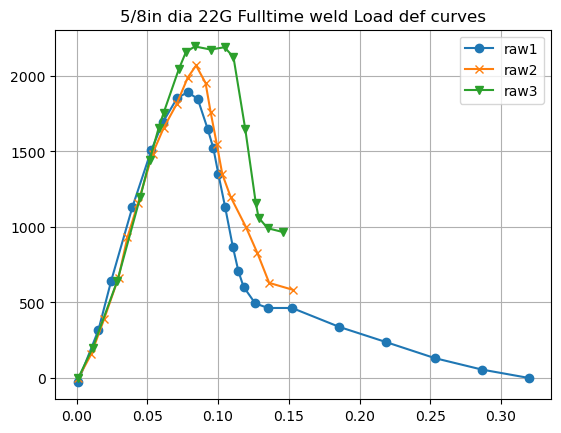

In [163]:
import math as m
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raw1 = np.array([
    [0.0007891770011273919, 332.2147651006708],
    [0.015388951521984204, 679.530201342282],
    [0.024464487034949245, 1006.7114093959731],
    [0.03945885005636976, 1494.96644295302],
    [0.05287485907553549, 1872.48322147651],
    [0.06116121758737317, 2058.7248322147652],
    [0.0710259301014656, 2214.7651006711408],
    [0.07852311161217584, 2255.0335570469797],
    [0.08562570462232241, 2209.731543624161],
    [0.09272829763246895, 2008.3892617449665],
    [0.09667418263810595, 1882.5503355704698],
    [0.10022547914317925, 1711.4093959731542],
    [0.1049605411499436, 1494.96644295302],
    [0.11048478015783539, 1228.1879194630872],
    [0.11443066516347236, 1067.1140939597312],
    [0.11798196166854563, 966.4429530201342],
    [0.12626832018038328, 855.7046979865768],
    [0.13534385569334836, 825.5033557046982],
    [0.15231116121758734, 825.5033557046982],
    [0.1858511837655017, 699.6644295302012],
    [0.2189966178128523, 598.9932885906042],
    [0.25332581736189397, 493.2885906040269],
    [0.2864712514092446, 417.78523489932877],
    [0.3196166854565952, 362.4161073825503]
])

raw2 = np.array([
    [0.0011837655016910809, 342.2818791946311],
    [0.010259301014656122, 498.3221476510066],
    [0.01933483652762119, 729.8657718120808],
    [0.029594137542277327, 1006.7114093959731],
    [0.03590755355129649, 1273.489932885906],
    [0.04340473506200675, 1499.9999999999998],
    [0.0536640360766629, 1827.1812080536913],
    [0.06155580608793684, 1998.3221476510066],
    [0.0706313416009019, 2154.362416107382],
    [0.07852311161217584, 2330.536912751678],
    [0.08444193912063133, 2411.0738255033557],
    [0.0911499436302142, 2295.302013422819],
    [0.09470124013528747, 2104.026845637584],
    [0.09904171364148814, 1892.6174496644296],
    [0.10298759864712512, 1691.2751677852348],
    [0.1089064261555806, 1540.2684563758387],
    [0.11956031567080044, 1343.959731543624],
    [0.12784667418263806, 1167.7852348993288],
    [0.13613303269447574, 971.4765100671138],
    [0.15270574971815104, 926.1744966442952]
])

raw3 = np.array([
    [0.0011837655016910809, 337.2483221476509],
    [0.01144306651634723, 538.5906040268455],
    [0.02880496054114992, 981.5436241610737],
    [0.044983089064261544, 1535.2348993288592],
    [0.05169109357384441, 1781.8791946308725],
    [0.05800450958286357, 1993.2885906040267],
    [0.06155580608793684, 2093.959731543624],
    [0.07220969560315671, 2380.8724832214766],
    [0.07733934611048476, 2496.6442953020132],
    [0.08365276211950393, 2531.8791946308725],
    [0.09470124013528747, 2511.744966442953],
    [0.1045659526493799, 2526.8456375838923],
    [0.11087936865839909, 2461.4093959731545],
    [0.11916572717023671, 1988.255033557047],
    [0.12666290868094698, 1494.96644295302],
    [0.12863585118376547, 1399.3288590604027],
    [0.13494926719278463, 1328.8590604026845],
    [0.1456031567080045, 1303.691275167785]
])

x1= raw1[:,0]
y1 = raw1[:,1]- 362.4161073825503
x2= raw2[:,0]
y2 = raw2[:,1]- 342.2818791946311
x3= raw3[:,0]
y3 = raw3[:,1]- 337.2483221476509
plt.figure()
plt.plot(x1,y1,marker='o',label="raw1")
plt.plot(x2,y2,marker='x',label="raw2")
plt.plot(x3,y3,marker='v',label="raw3")
plt.title('5/8in dia 22G Fulltime weld Load def curves')
plt.grid(True)
plt.legend()
plt.show()

In [165]:
def support_group(n_col, n_row, col_spacing, row_spacing):
    x_support = []
    y_support = []
    for i in range(n_col):
        for j in range(n_row):
            x_support.append(i * col_spacing - (n_col - 1) * col_spacing / 2)
            y_support.append(j * row_spacing - (n_row - 1) * row_spacing / 2)
    return x_support, y_support

In [167]:
def force_from_curve(delta_i, delta_tab,force_tab, normalize_by = None):
    # castining deformations and force values into numpy arrays b/c NumPy arrays let us do fast, vectorized math
    delta_tab = np.asarray(delta_tab,dtype=float) 
    force_tab = np.asarray(force_tab,dtype=float)
    x = np.asarray(delta_tab, float)
    y = np.asarray(force_tab, float)

    #cliping delta values to the range using clipping If value < min_val, it gets replaced by min_val. Same is true the other way
    xi = np.clip(np.asarray(delta_i, float), x.min(), x.max()) #so if delta_i is < minimum deformation it is xmin (same for xmax), this is b/c We don’t want to interpolate outside the tabulated data range. 
    f = np.interp(xi, x, y)              # capped interpolation
    f = np.clip(f, 0.0, y.max())         # guard against tiny numeric overshoots, f < 0.0 → set it to 0., If f > y.max() → set it to y.max().
    if normalize_by is not None:
        f = np.clip(f / float(normalize_by), 0.0, 1.0) # we are making sure Makes sure normalized FORCE results are always between 0 and 1. We use this
        # if we normalize by pf_arc
    return f

In [63]:
def ICM(x_load, y_load, x_coord, y_coord, fastener_types, ArcDataLabel, screw_params,delta_max):
    x_centroid, y_centroid = np.mean(x_coord), np.mean(y_coord)
    n = len(x_coord)

    
    raw = curves[ArcDataLabel]
    delta_tab = raw[:, 0]
    force_tab = raw[:, 1] / 1000
    P_f_arc = max(raw[:, 1]) / 1000  # corrected (was raw1)
    

    Ke, Ks, Kc, Kr = screw_params['Ke'], screw_params['Ks'], screw_params['Kc'], screw_params['Kr']
    dy, dc, dr, df_screw = screw_params['dy'], screw_params['dc'], screw_params['dr'], screw_params['df']
    Fc = screw_params['Fc']  # peak force for normalization

    # ---------- LOAD SETUP ----------
    hori_angle = 0
    vert_angle = 90 - hori_angle
    Py, Px = (-1.0 * m.cos(vert_angle * (m.pi / 180)), m.sin(vert_angle * (m.pi / 180)))  # kips (Py < 0 means downward)
    Mo = Py * x_load - Px * y_load  # kip-in, moment about centroid

    # ---------- POLAR MOMENT ----------
    J = ((x_coord - x_centroid)**2 + (y_coord - y_centroid)**2).sum()
    
    # ---------- INITIAL ELASTIC IC GUESS ----------
    x_ic = x_centroid + (-Py * J) / (n * Mo)
    y_ic = y_centroid + (Px * J) / (n * Mo)

    # ---------- ITERATION PARAMETERS ----------
    threshold = 1e-3
    F = np.inf
    max_iter = 200
    eps = 1e-12  # for safe division

   # ---------- ITERATION LOOP ----------
    for it in range(max_iter):
        
        # Compute applied moment about current IC
        Mp = Py * (x_load - x_ic) - Px * (y_load - y_ic)

        # Build DataFrame for this iteration
        df = pd.DataFrame({
        'x_coordinate': x_coord, 'y_coordinate': y_coord, 'Fastener type': fastener_types}, index=[f"Fastener {i}" for i in range(1, n + 1)])
        df['dx'] = df['x_coordinate'] - x_ic
        df['dy'] = df['y_coordinate'] - y_ic
        df['d'] = np.sqrt(df['dx']**2 + df['dy']**2)

        df['delta'] = delta_max * df['d'] / df['d'].max()

#    ---------- FORCE MODEL (ARC vs SCREW) ----------
        def get_force(row):
            t = row['Fastener type']
            if t in ('InteriorArc', 'EndArc', 'EdgeArc'):
                return force_from_curve(row['delta'], delta_tab, force_tab, normalize_by=P_f_arc)
            elif t == 'SideScrew':
                return screw_force(row['delta'], Ke, Ks, Kc, Kr, dy, dc, dr, df_screw) / Fc
            else:
                raise ValueError(f"Unknown fastener type: {t}")
                

        df['R/Rult'] = df.apply(get_force, axis=1)

   #     ---------- MOMENT AND FORCE BALANCE ----------
        df['M'] = df['R/Rult'] * df['d']
        sumMi = df['M'].sum()

        # Group ultimate scale factor
        Rult = -Mp / (sumMi + eps)
        Pult = sumMi / -Mp

        # Tangential components
        df['Rx'] = -(df['dy'] / (df['d'] + eps)) * df['R/Rult'] * Rult
        df['Ry'] = ((df['dx'] / (df['d'] + eps)) * df['R/Rult'] * Rult)


        # Residual (unbalanced) forces
        Fxx = (Px + df['Rx'].sum())*1
        Fyy = (Py + df['Ry'].sum())*1
        F = np.hypot(Fxx, Fyy)

      # Optional: print convergence every 10 iterations
        if it % 10 == 0:
            print(f"Iter {it:3d} | F = {F:.6e} | IC = ({x_ic:.2f}, {y_ic:.2f})")
            print(Fxx, Fyy)

        # Convergence check
        if F < threshold:
            print(f"Converged at iteration {it}, F = {F:.4e}")
            break

        # Update IC location (Brandt's update rule)
        x_ic = x_ic - (Fyy * J) / (n * Mo)
        y_ic = y_ic + (Fxx * J) / (n * Mo)

    # ---------- OUTPUT ----------
    return df, Pult, Mp, sumMi



In [175]:
def ICM1(x_load, y_load, x_coord, y_coord, fastener_types, ArcDataLabel, screw_params,delta_max,lamda):
    x_centroid, y_centroid = np.mean(x_coord), np.mean(y_coord)
    n = len(x_coord)

    
    raw = curves[ArcDataLabel]
    delta_tab = raw[:, 0]
    force_tab = raw[:, 1] / 1000
    P_f_arc = max(raw[:, 1]) / 1000  # corrected (was raw1)
    

    Ke, Ks, Kc, Kr = screw_params['Ke'], screw_params['Ks'], screw_params['Kc'], screw_params['Kr']
    dy, dc, dr, df_screw = screw_params['dy'], screw_params['dc'], screw_params['dr'], screw_params['df']
    Fc = screw_params['Fc']  # peak force for normalization

    # ---------- LOAD SETUP ----------
    hori_angle = 0
    vert_angle = 90 - hori_angle
    Py, Px = (-1.0 * m.cos(vert_angle * (m.pi / 180)), m.sin(vert_angle * (m.pi / 180)))  # kips (Py < 0 means downward)
    Mo = Py * x_load - Px * y_load  # kip-in, moment about centroid

    # ---------- POLAR MOMENT ----------
    J = ((x_coord - x_centroid)**2 + (y_coord - y_centroid)**2).sum()
    
    # ---------- INITIAL ELASTIC IC GUESS ----------
    x_ic = x_centroid + (-Py * J) / (n * Mo)
    y_ic = y_centroid + (Px * J) / (n * Mo)

    # ---------- ITERATION PARAMETERS ----------
    threshold = 1e-3
    F = np.inf
    max_iter = 200
    eps = 1e-12  # for safe division

   # ---------- ITERATION LOOP ----------
    for it in range(max_iter):
        # Compute applied moment about current IC
        Mp = Py * (x_load - x_ic) - Px * (y_load - y_ic)

        # Build DataFrame for this iteration
        df = pd.DataFrame({
        'x_coordinate': x_coord, 'y_coordinate': y_coord, 'Fastener type': fastener_types}, index=[f"Fastener {i}" for i in range(1, n + 1)])
        df['dx'] = df['x_coordinate'] - x_ic
        df['dy'] = df['y_coordinate'] - y_ic
        df['d'] = np.sqrt(df['dx']**2 + df['dy']**2)

        
# Computing deformation component _______________________________________________
        df['ux'] = df['dx'] / (df['d'] + eps)
        df['uy'] = df['dy'] / (df['d'] + eps)

        # unit tangential direction (perpendicular to radial)
        df['tx'] = -df['uy']
        df['ty'] =  df['ux']

        # choose theta so that max slip magnitude equals delta_max
        theta = delta_max / (df['d'].max() + eps)

        # tangential slip vector components (this is the deformation direction in ICM)
        df['delta_x'] = theta * df['d'] * df['tx']
        df['delta_y'] = theta * df['d'] * df['ty']

        # slip magnitude (what you were using before)
        df['delta'] = np.hypot(df['delta_x'], df['delta_y'])

        def get_force_components(row):
            alpha_y = 0
            t = row['Fastener type']
        
            # normalized force ratio based on slip magnitude
            if t in ('InteriorArc', 'EndArc', 'EdgeArc'):
                r = force_from_curve(row['delta'], delta_tab, force_tab, normalize_by=P_f_arc)
                if t == 'EndArc':
                    r *= lamda
                elif t == 'EdgeArc':
                    r *= lamda

            elif t == 'SideScrew':
                r = screw_force(row['delta'], Ke, Ks, Kc, Kr, dy, dc, dr, df_screw) / Fc
            else:
                raise ValueError(f"Unknown fastener type: {t}")
        
            # split that ratio into x/y components based on deformation direction
            # then weaken the y direction
            denom = (row['delta'] + eps)
            rx_ratio = r * (row['delta_x'] / denom)
            ry_ratio = r * (row['delta_y'] / denom) * alpha_y
        
            return pd.Series({'Rx_ratio': rx_ratio, 'Ry_ratio': ry_ratio})
        



        ratios = df.apply(get_force_components, axis=1)
        df = pd.concat([df, ratios], axis=1)

        df['R_ratio_mag'] = np.hypot(df['Rx_ratio'], df['Ry_ratio'])
        df['M'] = df['R_ratio_mag'] * df['d']
        sumMi = df['M'].sum()
        Rult = -Mp / (sumMi + eps)

        # Group ultimate scale factor
        Rult = -Mp / (sumMi + eps)
        Pult = sumMi / -Mp

        df['Rx'] = df['Rx_ratio'] * Rult
        df['Ry'] = df['Ry_ratio'] * Rult




        # Residual (unbalanced) forces
        Fxx = (Px + df['Rx'].sum())*1
        Fyy = (Py + df['Ry'].sum())*1
        F = np.hypot(Fxx, Fyy)

      # Optional: print convergence every 10 iterations
        if it % 10 == 0:
            print(f"Iter {it:3d} | F = {F:.6e} | IC = ({x_ic:.2f}, {y_ic:.2f})")

        # Convergence check
        if F < threshold:
            print(f"Converged at iteration {it}, F = {F:.4e}")
            break

        # Update IC location (Brandt's update rule)
        x_ic = x_ic - (Fyy * J) / (n * Mo)
        y_ic = y_ic + (Fxx * J) / (n * Mo)

    # ---------- OUTPUT ----------
    return df, Pult, Mp, sumMi,P_f_arc 



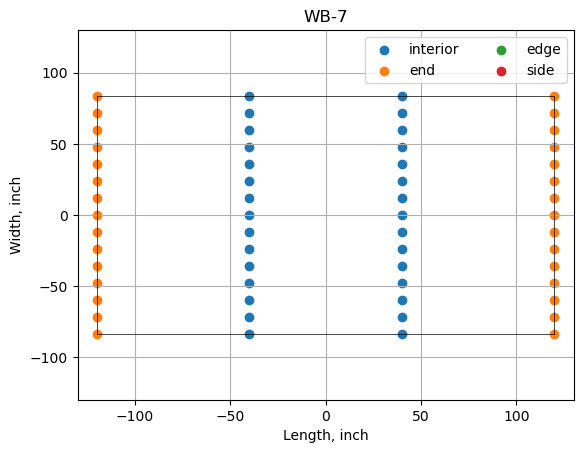

In [177]:
#WB 7
interior_x, interior_y = support_group(2,15,6*12+8, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-7')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [187]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 40.37,      # kip/in
    'Ks': 1.65,
    'Kc': -1.48,
    'Kr': -1.48,
    'dy': 0.0314,     # in
    'dc': 0.145,
    'dr': 0.519,
    'df': 1.02,
    'Fc': 1.29        # kip (≈ F_c)
}

Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = -120 , 96   # in
L = 20 


delta_max = 0.32 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.492))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.307))

Iter   0 | F = 5.562056e-01 | IC = (-0.00, -111.33)
Converged at iteration 1, F = 8.6652e-04
Shear strength =  12.05 kips
Shear strength =   0.60 kips/ft
ICM/EXP = 1.22 
ICM/AISI = 1.96 


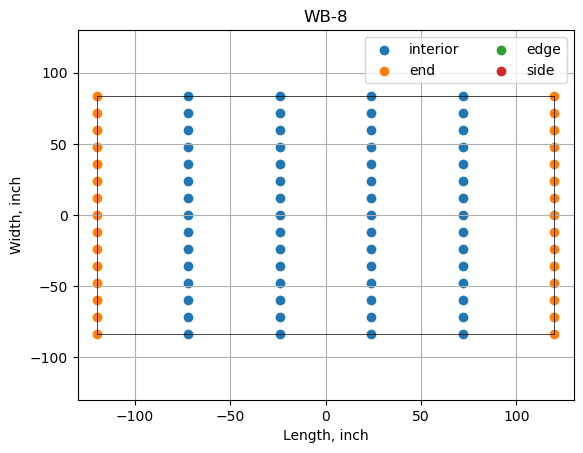

In [191]:
#WB 8
interior_x, interior_y = support_group(4,15,4*12, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-8')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [197]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 40.37,      # kip/in
    'Ks': 1.65,
    'Kc': -1.48,
    'Kr': -1.48,
    'dy': 0.0314,     # in
    'dc': 0.145,
    'dr': 0.519,
    'df': 1.02,
    'Fc': 1.29        # kip (≈ F_c)
}
Ls = (4*12)+0
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = -120 , 96   # in
L = 20 


delta_max = 0.32 #in #Used the max(screw,Arc) = Screw
strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)

print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.615))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.524))

Iter   0 | F = 5.575167e-01 | IC = (-0.00, -98.00)
Iter  10 | F = 3.803672e-01 | IC = (-0.00, -67.77)
Iter  20 | F = 4.050415e-01 | IC = (-0.00, -69.73)
Iter  30 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  40 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  50 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  60 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  70 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  80 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  90 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 100 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 110 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 120 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 130 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 140 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 150 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 160 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 170 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 180 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 190 | F = 4.050545e-01 | I

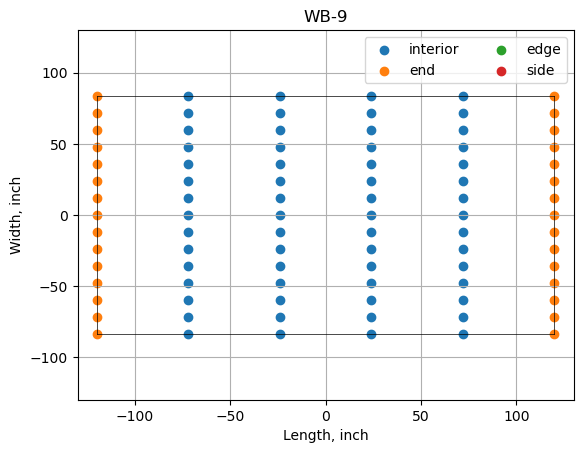

In [199]:
#WB 9
interior_x, interior_y = support_group(4,15,4*12, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-9')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [207]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 40.37,      # kip/in
    'Ks': 1.65,
    'Kc': -1.48,
    'Kr': -1.48,
    'dy': 0.0314,     # in
    'dc': 0.145,
    'dr': 0.519,
    'df': 1.02,
    'Fc': 1.29        # kip (≈ F_c)
}

Ls = (4*12)+0
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = -120 , 96   # in
L = 20 


delta_max = 0.32 #in #Used the max(screw,Arc) = Screw
strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types,3, screw_params,delta_max,lamda)

print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.423))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.558))

Iter   0 | F = 5.575167e-01 | IC = (-0.00, -98.00)
Iter  10 | F = 3.803672e-01 | IC = (-0.00, -67.77)
Iter  20 | F = 4.050415e-01 | IC = (-0.00, -69.73)
Iter  30 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  40 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  50 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  60 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  70 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  80 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter  90 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 100 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 110 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 120 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 130 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 140 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 150 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 160 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 170 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 180 | F = 4.050545e-01 | IC = (-0.00, -69.73)
Iter 190 | F = 4.050545e-01 | I

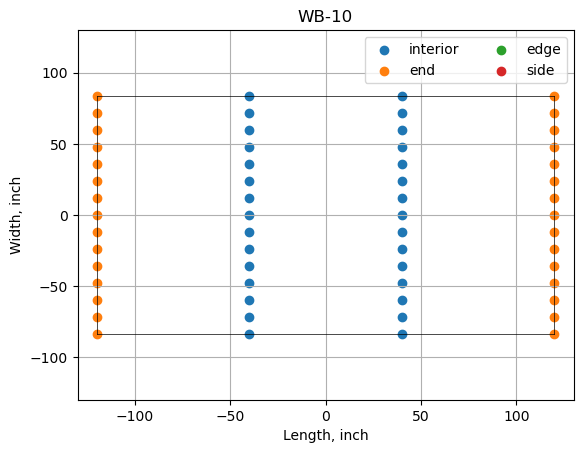

In [209]:
#WB 10
interior_x, interior_y = support_group(2,15,6*12+8, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-10')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [215]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 40.37,      # kip/in
    'Ks': 1.65,
    'Kc': -1.48,
    'Kr': -1.48,
    'dy': 0.0314,     # in
    'dc': 0.145,
    'dr': 0.519,
    'df': 1.02,
    'Fc': 1.29        # kip (≈ F_c)
}

Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = -120 , 96   # in
L = 20 

delta_max = 0.32 #in #Used the max(screw,Arc) = Screw
strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)

print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.311))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.267))

Iter   0 | F = 5.562056e-01 | IC = (-0.00, -111.33)
Converged at iteration 1, F = 8.6652e-04
Shear strength =  12.05 kips
Shear strength =   0.60 kips/ft
ICM/EXP = 1.94 
ICM/AISI = 2.26 


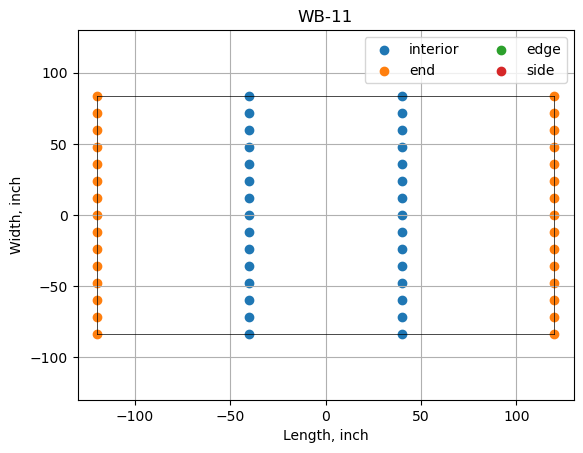

In [237]:
#WB 11
interior_x, interior_y = support_group(2,15,6*12+8, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-11')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [243]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)



Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
screw_params = {
    'Ke': 40.37,      # kip/in
    'Ks': 1.65,
    'Kc': -1.48,
    'Kr': -1.48,
    'dy': 0.0314,     # in
    'dc': 0.145,
    'dr': 0.519,
    'df': 1.02,
    'Fc': 1.29        # kip (≈ F_c)
}

x_load, y_load = -120 , 96   # in
L = 20 

delta_max = 0.32 #in #Used the max(screw,Arc) = Screw
strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 1, screw_params,delta_max,lamda)

print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.339))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.267))

Iter   0 | F = 7.743147e-01 | IC = (-0.00, -111.33)
Iter  10 | F = 7.771980e-01 | IC = (-0.00, -93.22)
Iter  20 | F = 7.846295e-01 | IC = (-0.00, -105.09)
Iter  30 | F = 7.857065e-01 | IC = (-0.00, -98.42)
Iter  40 | F = 7.869026e-01 | IC = (-0.00, -101.93)
Iter  50 | F = 7.867812e-01 | IC = (-0.00, -100.25)
Iter  60 | F = 7.869836e-01 | IC = (-0.00, -101.20)
Iter  70 | F = 7.868572e-01 | IC = (-0.00, -100.68)
Iter  80 | F = 7.869268e-01 | IC = (-0.00, -100.94)
Iter  90 | F = 7.868961e-01 | IC = (-0.00, -100.82)
Iter 100 | F = 7.869109e-01 | IC = (-0.00, -100.87)
Iter 110 | F = 7.869041e-01 | IC = (-0.00, -100.85)
Iter 120 | F = 7.869073e-01 | IC = (-0.00, -100.86)
Iter 130 | F = 7.869058e-01 | IC = (-0.00, -100.85)
Iter 140 | F = 7.869065e-01 | IC = (-0.00, -100.86)
Iter 150 | F = 7.869062e-01 | IC = (-0.00, -100.85)
Iter 160 | F = 7.869063e-01 | IC = (-0.00, -100.85)
Iter 170 | F = 7.869063e-01 | IC = (-0.00, -100.85)
Iter 180 | F = 7.869063e-01 | IC = (-0.00, -100.85)
Iter 190 | F =

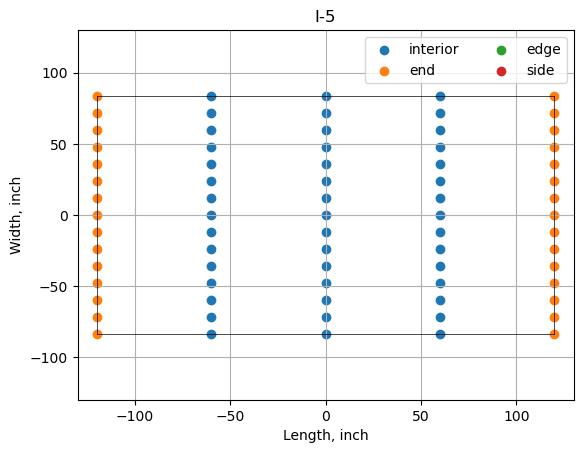

In [245]:
#I-5
interior_x, interior_y = support_group(3,15,5*12, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('I-5')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [251]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 40.37,      # kip/in
    'Ks': 1.65,
    'Kc': -1.48,
    'Kr': -1.48,
    'dy': 0.0314,     # in
    'dc': 0.145,
    'dr': 0.519,
    'df': 1.02,
    'Fc': 1.29        # kip (≈ F_c)
}

Ls = (5*12)+0
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = -120 , 96   # in
L = 20 

delta_max = 0.32 #in #Used the max(screw,Arc) = Screw
strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 1, screw_params,delta_max,lamda)





print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.315))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.386))

Iter   0 | F = 7.839450e-01 | IC = (-0.00, -103.00)
Iter  10 | F = 7.770293e-01 | IC = (-0.00, -89.60)
Iter  20 | F = 7.851847e-01 | IC = (-0.00, -97.78)
Iter  30 | F = 7.773540e-01 | IC = (-0.00, -89.82)
Iter  40 | F = 7.851820e-01 | IC = (-0.00, -97.77)
Iter  50 | F = 7.773544e-01 | IC = (-0.00, -89.82)
Iter  60 | F = 7.851820e-01 | IC = (-0.00, -97.77)
Iter  70 | F = 7.773544e-01 | IC = (-0.00, -89.82)
Iter  80 | F = 7.851820e-01 | IC = (-0.00, -97.77)
Iter  90 | F = 7.773544e-01 | IC = (-0.00, -89.82)
Iter 100 | F = 7.851820e-01 | IC = (-0.00, -97.77)
Iter 110 | F = 7.773544e-01 | IC = (-0.00, -89.82)
Iter 120 | F = 7.851820e-01 | IC = (-0.00, -97.77)
Iter 130 | F = 7.773544e-01 | IC = (-0.00, -89.82)
Iter 140 | F = 7.851820e-01 | IC = (-0.00, -97.77)
Iter 150 | F = 7.773544e-01 | IC = (-0.00, -89.82)
Iter 160 | F = 7.851820e-01 | IC = (-0.00, -97.77)
Iter 170 | F = 7.773544e-01 | IC = (-0.00, -89.82)
Iter 180 | F = 7.851820e-01 | IC = (-0.00, -97.77)
Iter 190 | F = 7.773544e-01 | 

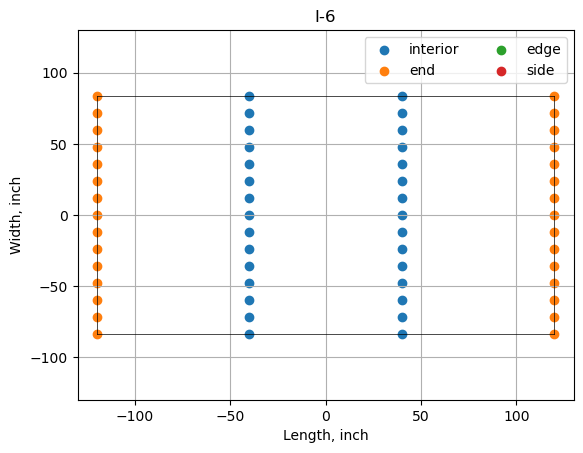

In [253]:
#I-6
interior_x, interior_y = support_group(2,15,6*12+8, 12) #purlin
end_x, end_y = support_group(2,15,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('I-6')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [259]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 40.37,      # kip/in
    'Ks': 1.65,
    'Kc': -1.48,
    'Kr': -1.48,
    'dy': 0.0314,     # in
    'dc': 0.145,
    'dr': 0.519,
    'df': 1.02,
    'Fc': 1.29        # kip (≈ F_c)
}

Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = -120 , 96   # in
L = 20 

delta_max = 0.32 #in #Used the max(screw,Arc) = Screw
strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 1, screw_params,delta_max,lamda)

print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.275))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.288))

Iter   0 | F = 7.743147e-01 | IC = (-0.00, -111.33)
Iter  10 | F = 7.771980e-01 | IC = (-0.00, -93.22)
Iter  20 | F = 7.846295e-01 | IC = (-0.00, -105.09)
Iter  30 | F = 7.857065e-01 | IC = (-0.00, -98.42)
Iter  40 | F = 7.869026e-01 | IC = (-0.00, -101.93)
Iter  50 | F = 7.867812e-01 | IC = (-0.00, -100.25)
Iter  60 | F = 7.869836e-01 | IC = (-0.00, -101.20)
Iter  70 | F = 7.868572e-01 | IC = (-0.00, -100.68)
Iter  80 | F = 7.869268e-01 | IC = (-0.00, -100.94)
Iter  90 | F = 7.868961e-01 | IC = (-0.00, -100.82)
Iter 100 | F = 7.869109e-01 | IC = (-0.00, -100.87)
Iter 110 | F = 7.869041e-01 | IC = (-0.00, -100.85)
Iter 120 | F = 7.869073e-01 | IC = (-0.00, -100.86)
Iter 130 | F = 7.869058e-01 | IC = (-0.00, -100.85)
Iter 140 | F = 7.869065e-01 | IC = (-0.00, -100.86)
Iter 150 | F = 7.869062e-01 | IC = (-0.00, -100.85)
Iter 160 | F = 7.869063e-01 | IC = (-0.00, -100.85)
Iter 170 | F = 7.869063e-01 | IC = (-0.00, -100.85)
Iter 180 | F = 7.869063e-01 | IC = (-0.00, -100.85)
Iter 190 | F =